In [1]:
import pandas as pd
from lxml.parser import result

In [2]:
doi_csv = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec_DOI.csv")
dois = list(doi_csv["RetractionDOI"])

In [ ]:
import requests

# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     # Add more DOIs as needed
# ]

for doi in dois:
    response = requests.get(f'https://api.openalex.org/works/https://doi.org/{doi}')
    if response.status_code == 200:
        data = response.json()
        # Process the data as needed
        print(data)
    else:
        print(f'Error retrieving data for DOI: {doi}')

In [3]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003'
# ]

# List to store results
data_list = []

# Fetch data from OpenAlex API
for doi in dois:
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        data_list.append({
            "DOI": doi,
            "Title": data.get("title", "N/A"),
            "Authors": ", ".join([author.get("author", {}).get("display_name", "Unknown") for author in data.get("authorships", [])]),
            "Year": data.get("publication_year", "N/A"),
            "Journal": data.get("primary_location", {}).get("source", {}).get("display_name", "N/A"),
            "Citations": data.get("cited_by_count", "N/A"),
            "OpenAlex_ID": data.get("id", "N/A")
        })
    else:
        data_list.append({
            "DOI": doi,
            "Title": "Error retrieving data",
            "Authors": "N/A",
            "Year": "N/A",
            "Journal": "N/A",
            "Citations": "N/A",
            "OpenAlex_ID": "N/A"
        })

# Convert to DataFrame
df = pd.DataFrame(data_list)

# Display DataFrame
import ace_tools as tools
tools.display_dataframe_to_user(name="OpenAlex Article Data", dataframe=df)


AttributeError: 'NoneType' object has no attribute 'get'

In [7]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     '10.7717/peerj.4375'
# ]

# List to store article information
articles = []

# Fetch data from OpenAlex API
for doi in dois:
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Handle cases where data might be None
        title = data.get('title', 'N/A')
        authors = data.get('authorships', [])
        authors_str = ', '.join([author['author']['display_name'] for author in authors if author.get('author')]) if authors else 'N/A'
        publication_year = data.get('publication_year', 'N/A')
        journal = data.get('host_venue', {}).get('display_name', 'N/A') if data.get('host_venue') else 'N/A'
        cited_by_count = data.get('cited_by_count', 'N/A')
        openalex_id = data.get('id', 'N/A')
        url_doi = data.get('doi', 'N/A')

        articles.append({
            'DOI': doi,
            'Title': title,
            'Authors': authors_str,
            'Publication Year': publication_year,
            'Journal': journal,
            'Cited By Count': cited_by_count,
            'OpenAlex ID': openalex_id,
            'URL': url_doi
        })
    else:
        articles.append({
            'DOI': doi,
            'Title': 'Error retrieving data',
            'Authors': 'N/A',
            'Publication Year': 'N/A',
            'Journal': 'N/A',
            'Cited By Count': 'N/A',
            'OpenAlex ID': 'N/A',
            'URL': 'N/A'
        })

# Create a DataFrame
df = pd.DataFrame(articles)

# Save to CSV
df.to_csv('openalex_articles.csv', index=False)

In [8]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     '10.7717/peerj.4375'
# ]

# Function to get citations and references for a DOI
def get_citation_details(doi):
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Extracting basic details
        title = data.get('title', 'N/A')
        openalex_id = data.get('id', 'N/A')

        # Getting list of works that this article cites
        references = data.get('referenced_works', [])

        # Getting the list of works that cite this article
        cited_by_url = f'https://api.openalex.org/works/{openalex_id}/cited_by'
        cited_by_response = requests.get(cited_by_url)
        cited_by_list = []

        if cited_by_response.status_code == 200:
            cited_by_data = cited_by_response.json()
            cited_by_list = [work['id'] for work in cited_by_data.get('results', [])]

        return {
            'DOI': doi,
            'Title': title,
            'OpenAlex ID': openalex_id,
            'Cited By': cited_by_list,
            'References': references
        }
    else:
        return {
            'DOI': doi,
            'Title': 'Error retrieving data',
            'OpenAlex ID': 'N/A',
            'Cited By': 'N/A',
            'References': 'N/A'
        }

# Fetch citation details for all DOIs
citation_data = [get_citation_details(doi) for doi in dois]

# Convert to DataFrame
df_citations = pd.DataFrame(citation_data)

# Save to CSV
df_citations.to_csv('citation_details.csv', index=False)

In [9]:
citeDetail = pd.read_csv('citation_details.csv')
retractedDataSet = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

In [10]:
citeDetail

,DOI,Title,OpenAlex ID,Cited By,References
0,10.1155/2023/9865791,Retracted: An Architectural Framework for Heal...,https://openalex.org/W4388124931,[],['https://openalex.org/W3210178340']
1,10.1155/2023/9859342,Retracted: Clustering of Brain Tumor Based on ...,https://openalex.org/W4389127150,[],['https://openalex.org/W3198441341']
2,10.1155/2023/9849356,Retracted: Using a Blur Metric to Estimate Lin...,https://openalex.org/W4389381587,[],['https://openalex.org/W3210201227']
3,10.1155/2023/9831958,Retracted: Method of Cumulative Anomaly Identi...,https://openalex.org/W4389371056,[],['https://openalex.org/W4220766059']
4,10.1155/2023/9854302,Retracted: A Computer‐Aided Method for Digesti...,https://openalex.org/W4389398875,[],['https://openalex.org/W3206639986']
...,...,...,...,...,...
161,10.1007/978-3-319-42092-9_48,Retraction Note to: A Novel Voting Mathematica...,https://openalex.org/W2563871704,[],[]
162,10.1016/j.jvcir.2014.05.007,Retraction Note to “Pose invariant face recogn...,https://openalex.org/W2052373026,[],[]
163,10.1109/ICETC.2009.12,Notice of Retraction: Fuzzy PID Sliding Mode C...,https://openalex.org/W1961499357,[],"['https://openalex.org/W11567962', 'https://op..."
164,10.1142/S0219622013930012,STATEMENT OF RETRACTION — A LAGRANGIAN-BASED S...,https://openalex.org/W2075085261,[],[]


In [11]:
compDf = pd.read_csv(r"C:\Users\Parsa\Downloads\Merged_Retraction___Citation_Data.csv")

In [14]:
for index, row in compDf.iterrows():
    if(row['DOI'] == row['RetractionDOI']):
        continue
    else:
        print(index)

56
67
98


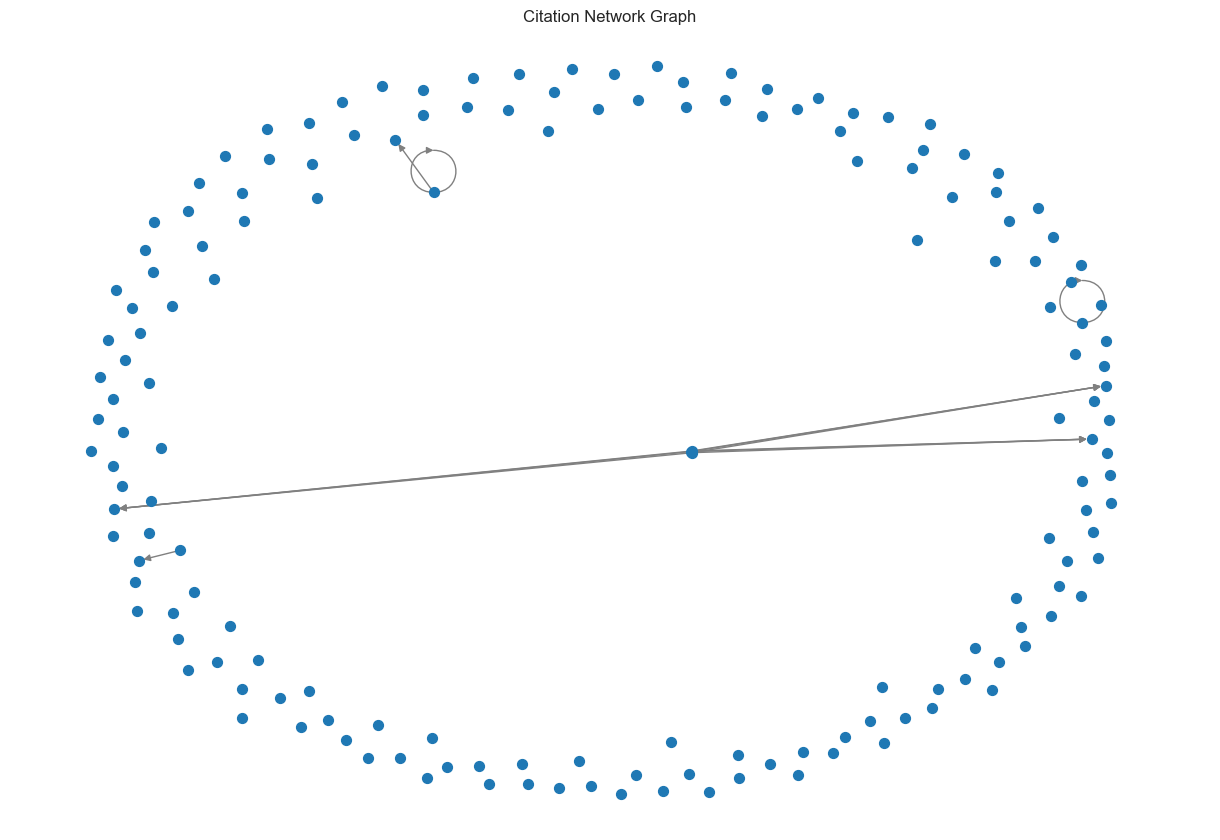

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the merged dataset
merged_file_path = r"C:\Users\Parsa\Downloads\Merged_Retraction___Citation_Data.csv"
df = pd.read_csv(merged_file_path)

# Create a directed graph
G = nx.DiGraph()

# Add nodes (articles) to the graph
for index, row in df.iterrows():
    article_id = row["OpenAlex ID"]
    if pd.notna(article_id):
        G.add_node(article_id, title=row.get("Title", "Unknown"))

# Add edges (citation relationships)
for index, row in df.iterrows():
    article_id = row["OpenAlex ID"]
    if pd.notna(article_id) and pd.notna(row["References"]):
        references = row["References"]

        # Handle case where references are stored as a string representation of a list
        if isinstance(references, str):
            references = references.strip("[]").replace("'", "").split(", ")

        for ref in references:
            if ref in G.nodes:
                G.add_edge(article_id, ref)

# Plot the citation graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Layout for better visualization
nx.draw(G, pos, with_labels=False, node_size=50, edge_color="gray")
plt.title("Citation Network Graph")
plt.show()

In [9]:
doi_csv = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec_DOI.csv")
dois = list(doi_csv["RetractionDOI"])

In [5]:
import requests
import json
import time

# Your email for the polite pool
EMAIL = "parsazahedizzz@gmail.com"  # Replace with your real email

# List of DOIs to query
# doi_list = [
#     "10.1109/5.771073",
#     "10.1145/3373376.3373382",
#     "10.1016/j.jaci.2020.08.019"
# ]  # Replace with your list of DOIs

# OpenAlex API base URL
BASE_URL = "https://api.openalex.org/works"

# Function to get metadata for a batch of DOIs
def fetch_openalex_data(doi_list):
    """
    Fetches metadata for a list of DOIs from OpenAlex API.
    """
    # Convert DOIs into OpenAlex ID format (https://doi.org/ prefix)
    openalex_ids = [f"https://doi.org/{doi}" for doi in doi_list]

    # API query parameters
    params = {
        "filter": f"id.in: {','.join(openalex_ids)}",
        "mailto": EMAIL  # Using polite pool
    }

    headers = {
        "User-Agent": f"MyResearchBot/1.0 (mailto:{EMAIL})"
    }

    # Make the request
    response = requests.get(BASE_URL, params=params, headers=headers)

    # Handle request errors
    if response.status_code != 200:
        print(f"Error {response.status_code}: {response.text}")
        return None

    return response.json()

# Fetch data
print("Fetching data from OpenAlex...")
data = fetch_openalex_data(doi_list)

# Save the response as JSON
if data:
    with open("openalex_results.json", "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)
    print("Results saved to openalex_results.json")
else:
    print("No data retrieved.")


Fetching data from OpenAlex...
Error 414: 
No data retrieved.


In [1]:
import pandas as pd
doi_csv = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec_DOI.csv")
dois = list(doi_csv["RetractionDOI"])

In [2]:
from pyalex import Works, config

# Set your email to join the polite pool
config.email = "parsazahedizzz@gmail.com"

# Function to retrieve article information based on DOIs
def get_article_info(dois):
    articles = []
    for doi in dois:
        try:
            work = Works()[f"https://doi.org/{doi}"]
            articles.append(work)
        except Exception as e:
            print(f"Error retrieving DOI {doi}: {e}")
    return articles

# Retrieve article information
article_info = get_article_info(dois)

In [4]:
len(article_info)

166

In [15]:
for index,article in enumerate(article_info):
    if article['cited_by_count'] > 15:
        print(index, article['cited_by_count'])

47 117
64 21
121 29
132 21
138 21
143 21
148 17
159 16


In [17]:
for index,article in enumerate(article_info):
    if(article['title'] == "Retraction Note To: Artificial neural network to predict the effect of heat treatments on Vickers microhardness of low-carbon Nb microalloyed steels"):
        print(index)

68


In [20]:
article_info[68]

{'id': 'https://openalex.org/W3120590686',
 'doi': 'https://doi.org/10.1007/s00521-020-05575-2',
 'title': 'Retraction Note To: Artificial neural network to predict the effect of heat treatments on Vickers microhardness of low-carbon Nb microalloyed steels',
 'display_name': 'Retraction Note To: Artificial neural network to predict the effect of heat treatments on Vickers microhardness of low-carbon Nb microalloyed steels',
 'publication_year': 2021,
 'publication_date': '2021-01-11',
 'ids': {'openalex': 'https://openalex.org/W3120590686',
  'doi': 'https://doi.org/10.1007/s00521-020-05575-2',
  'mag': '3120590686'},
 'language': 'en',
 'primary_location': {'is_oa': True,
  'landing_page_url': 'https://doi.org/10.1007/s00521-020-05575-2',
  'pdf_url': 'https://link.springer.com/content/pdf/10.1007/s00521-020-05575-2.pdf',
  'source': {'id': 'https://openalex.org/S147897268',
   'display_name': 'Neural Computing and Applications',
   'issn_l': '0941-0643',
   'issn': ['0941-0643', '143

In [ ]:
#TODO
#find out how many retracted papers each one of these authors of influential articles have

In [2]:

#Top 3 Betweeness of retracted papers
#1004	https://openalex.org/W2029538206	65.83333333333331(betweeness), 0.040178589999054264(eigenvector centrality)
#481	    https://openalex.org/W3120590686	46.0(betweeness), 0.013392863333018088(eigenvector centrality))
#1010	https://openalex.org/W2077146256	20.833333333333332(betweeness), 0.040178589999054264(eigenvector centrality)

'\nTop 3 Betweeness\n1004\thttps://openalex.org/W2029538206\t65.83333333333331(betweeness)), 0.040178589999054264(eigenvector centerality)\n481\t    https://openalex.org/W3120590686\t46.0\n1010\thttps://openalex.org/W2077146256\t20.833333333333332\n\n'

In [13]:
for index,article in enumerate(article_info):
    if not article['is_retracted']:
        print(index, article['updated_date'])

0 2025-02-05T01:49:33.087760
1 2025-02-05T01:49:50.884329
2 2025-02-05T01:50:33.014209
3 2025-02-05T01:49:51.684467
4 2025-02-05T01:50:10.251197
5 2025-01-31T11:54:03.443358
6 2025-02-05T01:50:33.321192
7 2025-02-05T04:54:51.824022
8 2025-02-01T16:13:01.603764
9 2025-02-01T05:38:47.414332
10 2025-02-05T01:46:33.535533
11 2025-02-05T04:45:44.168943
12 2025-02-02T16:00:27.550254
13 2025-02-04T18:06:53.089562
14 2025-01-24T14:03:54.312833
15 2025-02-03T14:03:21.075336
16 2025-02-05T01:46:18.526550
17 2025-02-05T01:46:33.280712
18 2025-02-07T06:15:43.743358
21 2025-02-05T17:24:14.824364
22 2025-01-20T22:11:14.854321
23 2025-01-29T10:14:20.977720
24 2025-02-05T01:46:51.951092
25 2025-02-05T01:47:01.013472
26 2025-02-06T04:37:11.684589
27 2025-01-26T01:46:07.229805
28 2025-02-02T21:09:22.961052
29 2025-02-02T20:56:53.592285
30 2025-02-02T20:09:41.489969
31 2025-02-02T21:24:45.981564
35 2025-01-18T02:05:01.599934
36 2025-02-01T12:05:51.261003
39 2025-02-03T08:22:58.129629
41 2025-01-28T19:33:

In [15]:
article_info[0]['title']

'Retracted: An Architectural Framework for Healthcare Dashboards Design'

In [17]:
article_info[114].keys()

dict_keys(['id', 'doi', 'title', 'display_name', 'publication_year', 'publication_date', 'ids', 'language', 'primary_location', 'type', 'type_crossref', 'indexed_in', 'open_access', 'authorships', 'institution_assertions', 'countries_distinct_count', 'institutions_distinct_count', 'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci', 'has_fulltext', 'cited_by_count', 'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext', 'primary_topic', 'topics', 'keywords', 'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location', 'sustainable_development_goals', 'grants', 'datasets', 'versions', 'referenced_works_count', 'referenced_works', 'related_works', 'abstract_inverted_index', 'abstract_inverted_index_v3', 'cited_by_api_url', 'counts_by_year', 'updated_date', 'created_date'])

In [18]:
article_info[114]['id']

'https://openalex.org/W2110996721'

In [16]:
article_info[114]['referenced_works']

['https://openalex.org/W18071849',
 'https://openalex.org/W1967541793',
 'https://openalex.org/W1968985240',
 'https://openalex.org/W1999883131',
 'https://openalex.org/W2006962765',
 'https://openalex.org/W2024350994',
 'https://openalex.org/W2027197837',
 'https://openalex.org/W2029538206',
 'https://openalex.org/W2033011996',
 'https://openalex.org/W2035306825',
 'https://openalex.org/W2061871963',
 'https://openalex.org/W2066210005',
 'https://openalex.org/W2077146256',
 'https://openalex.org/W2090294469',
 'https://openalex.org/W2119576674',
 'https://openalex.org/W2122922428',
 'https://openalex.org/W2129272928',
 'https://openalex.org/W2136226282',
 'https://openalex.org/W2137983211',
 'https://openalex.org/W2145085734',
 'https://openalex.org/W2181894086',
 'https://openalex.org/W2301676159',
 'https://openalex.org/W2331880329']

In [23]:
article_info[114]['authorships'][0]

{'author_position': 'first',
 'author': {'id': 'https://openalex.org/A5053388446',
  'display_name': 'Mohammad Ali Ahmadi',
  'orcid': 'https://orcid.org/0000-0002-8229-334X'},
 'institutions': [{'id': 'https://openalex.org/I154127411',
   'display_name': 'Petroleum University of Technology',
   'ror': 'https://ror.org/00r0xhf81',
   'country_code': 'IR',
   'type': 'education',
   'lineage': ['https://openalex.org/I154127411']}],
 'countries': ['IR'],
 'is_corresponding': False,
 'raw_author_name': 'Mohammad Ali Ahmadi',
 'raw_affiliation_strings': ['Petroleum University of technology'],
 'affiliations': [{'raw_affiliation_string': 'Petroleum University of technology',
   'institution_ids': ['https://openalex.org/I154127411']}]}

In [11]:
top3_highest_cited = [float('-inf')] * 3
for index, article in enumerate(article_info):
    if article['cited_by_count'] > top3_highest_cited[0]:
        top3_highest_cited = sorted([article['cited_by_count']] + top3_highest_cited[:2], reverse=True)

In [12]:
#referenced_works_count is what i want
top3_highest_cited

[117, 15, 0]

In [40]:
article_info[100]['authorships']

[{'author_position': 'first',
  'author': {'id': 'https://openalex.org/A5086875707',
   'display_name': 'Tayebeh Hosseinnejad',
   'orcid': 'https://orcid.org/0000-0003-1996-016X'},
  'institutions': [{'id': 'https://openalex.org/I67080706',
    'display_name': 'Alzahra University',
    'ror': 'https://ror.org/013cdqc34',
    'country_code': 'IR',
    'type': 'funder',
    'lineage': ['https://openalex.org/I67080706']}],
  'countries': ['IR'],
  'is_corresponding': False,
  'raw_author_name': 'Tayebeh Hosseinnejad',
  'raw_affiliation_strings': ['Department of Chemistry , Alzahra University , Vanak, Tehran, Iran'],
  'affiliations': [{'raw_affiliation_string': 'Department of Chemistry , Alzahra University , Vanak, Tehran, Iran',
    'institution_ids': ['https://openalex.org/I67080706']}]},
 {'author_position': 'middle',
  'author': {'id': 'https://openalex.org/A5002637505',
   'display_name': 'Bahareh Fattahi',
   'orcid': None},
  'institutions': [{'id': 'https://openalex.org/I6708070

In [39]:
article_info[65]['authorships']

[{'author_position': 'first',
  'author': {'id': 'https://openalex.org/A5057091183',
   'display_name': 'Mahmoud Reza Saybani',
   'orcid': 'https://orcid.org/0000-0001-7643-1091'},
  'institutions': [{'id': 'https://openalex.org/I33849332',
    'display_name': 'University of Malaya',
    'ror': 'https://ror.org/00rzspn62',
    'country_code': 'MY',
    'type': 'funder',
    'lineage': ['https://openalex.org/I33849332']}],
  'countries': ['MY'],
  'is_corresponding': True,
  'raw_author_name': 'Mahmoud Reza Saybani',
  'raw_affiliation_strings': ['Department of Information Systems, Faculty of Computer Science and Information Technology, University of Malaya, 50603, Kula Lumpur, Malaysia'],
  'affiliations': [{'raw_affiliation_string': 'Department of Information Systems, Faculty of Computer Science and Information Technology, University of Malaya, 50603, Kula Lumpur, Malaysia',
    'institution_ids': ['https://openalex.org/I33849332']}]},
 {'author_position': 'middle',
  'author': {'id'

In [44]:
article_info[47]['authorships']

[{'author_position': 'first',
  'author': {'id': 'https://openalex.org/A5028765261',
   'display_name': 'Rahim Ali Abbaspour',
   'orcid': 'https://orcid.org/0000-0002-7133-3844'},
  'institutions': [{'id': 'https://openalex.org/I23946033',
    'display_name': 'University of Tehran',
    'ror': 'https://ror.org/05vf56z40',
    'country_code': 'IR',
    'type': 'funder',
    'lineage': ['https://openalex.org/I23946033']}],
  'countries': ['IR'],
  'is_corresponding': False,
  'raw_author_name': 'Rahim A. Abbaspour',
  'raw_affiliation_strings': [' Surveying Engineering Department, College of Engineering, University of Tehran, Tehran, Iran'],
  'affiliations': [{'raw_affiliation_string': ' Surveying Engineering Department, College of Engineering, University of Tehran, Tehran, Iran',
    'institution_ids': ['https://openalex.org/I23946033']}]},
 {'author_position': 'last',
  'author': {'id': 'https://openalex.org/A5062957503',
   'display_name': 'Farhad Samadzadegan',
   'orcid': 'https:/

In [50]:
# Write to a text file in JSON format
import json
with open("output.txt", "w") as file:
    json.dump(article_info, file, indent=4)  # `indent=4` makes it readable

In [46]:
article_info

[{'id': 'https://openalex.org/W4388124931',
  'doi': 'https://doi.org/10.1155/2023/9865791',
  'title': 'Retracted: An Architectural Framework for Healthcare Dashboards Design',
  'display_name': 'Retracted: An Architectural Framework for Healthcare Dashboards Design',
  'publication_year': 2023,
  'publication_date': '2023-01-01',
  'ids': {'openalex': 'https://openalex.org/W4388124931',
   'doi': 'https://doi.org/10.1155/2023/9865791',
   'pmid': 'https://pubmed.ncbi.nlm.nih.gov/37946909'},
  'language': 'en',
  'primary_location': {'is_oa': True,
   'landing_page_url': 'https://doi.org/10.1155/2023/9865791',
   'pdf_url': 'https://downloads.hindawi.com/journals/jhe/2023/9865791.pdf',
   'source': {'id': 'https://openalex.org/S36625193',
    'display_name': 'Journal of Healthcare Engineering',
    'issn_l': '2040-2295',
    'issn': ['2040-2295', '2040-2309'],
    'is_oa': True,
    'is_in_doaj': False,
    'is_indexed_in_scopus': False,
    'is_core': True,
    'host_organization': '

In [24]:
import json
from collections import defaultdict

# Load the dataset
# file_path = "/mnt/data/pyalexDumpJSON.txt"
#
# with open(file_path, "r", encoding="utf-8") as f:
#     data = json.load(f)

# Initialize a dictionary to store articles authored by each author
author_articles = defaultdict(set)

# Populate author to articles mapping
for article in article_info:
    article_id = article["id"]
    for authorship in article["authorships"]:
        author_id = authorship["author"]["id"]
        author_articles[author_id].add(article_id)

# Calculate self-citations
self_citations = defaultdict(int)

for article in article_info:
    article_id = article["id"]
    referenced_works = article.get("referenced_works", [])

    # Get authors of the current article
    article_authors = {authorship["author"]["id"] for authorship in article["authorships"]}

    for ref_id in referenced_works:
        # Check if the referenced work is authored by any of the article's authors
        for author in article_authors:
            if ref_id in author_articles[author]:
                self_citations[author] += 1

# Display self-citation counts
# for author, count in self_citations.items():
#     print(f"Author ID: {author}, Self-Citations: {count}")


In [25]:
self_citations

defaultdict(int,
            {'https://openalex.org/A5015822427': 1,
             'https://openalex.org/A5067828278': 1,
             'https://openalex.org/A5078248683': 1,
             'https://openalex.org/A5016730502': 1,
             'https://openalex.org/A5101715046': 1,
             'https://openalex.org/A5029406867': 1,
             'https://openalex.org/A5108553064': 1,
             'https://openalex.org/A5070749542': 1,
             'https://openalex.org/A5054453620': 2,
             'https://openalex.org/A5111972280': 2,
             'https://openalex.org/A5103395335': 1,
             'https://openalex.org/A5010028202': 2,
             'https://openalex.org/A5076204864': 2,
             'https://openalex.org/A5102711389': 2,
             'https://openalex.org/A5007635991': 2,
             'https://openalex.org/A5058384543': 9,
             'https://openalex.org/A5053388446': 9})

In [30]:
import json
from collections import defaultdict

# Load the dataset
# file_path = "/mnt/data/pyalexDumpJSON.txt"
#
# with open(file_path, "r", encoding="utf-8") as f:
#     data = json.load(f)

# Initialize a dictionary to store articles authored by each author
author_articles = defaultdict(set)

# Populate author-to-articles mapping
for article in article_info:
    article_id = article["id"]
    for authorship in article["authorships"]:
        author_id = authorship["author"]["id"]
        author_articles[author_id].add(article_id)

# Dictionary to store self-citation counts and involved articles
self_citations = defaultdict(lambda: {"count": 0, "articles": set()})

# Calculate self-citations
for article in article_info:
    article_id = article["id"]
    referenced_works = article.get("referenced_works", [])

    # Get authors of the current article
    article_authors = {authorship["author"]["id"] for authorship in article["authorships"]}

    for ref_id in referenced_works:
        # Check if the referenced work is authored by any of the article's authors
        for author in article_authors:
            if ref_id in author_articles[author]:
                self_citations[author]["count"] += 1
                self_citations[author]["articles"].add((article_id, ref_id))

# Display self-citation counts and articles involved
for author, article_info in self_citations.items():
    print(f"Author ID: {author}")
    print(f"Self-Citation Count: {article_info['count']}")
    print("Articles Involved (Citing Article -> Referenced Article):")
    for citing_article, referenced_article in article_info["articles"]:
        print(f"  {citing_article} -> {referenced_article}")
    print("-" * 50)


Author ID: https://openalex.org/A5015822427
Self-Citation Count: 1
Articles Involved (Citing Article -> Referenced Article):
  https://openalex.org/W2952371127 -> https://openalex.org/W2952371127
--------------------------------------------------
Author ID: https://openalex.org/A5067828278
Self-Citation Count: 1
Articles Involved (Citing Article -> Referenced Article):
  https://openalex.org/W2952371127 -> https://openalex.org/W2952371127
--------------------------------------------------
Author ID: https://openalex.org/A5078248683
Self-Citation Count: 1
Articles Involved (Citing Article -> Referenced Article):
  https://openalex.org/W2952371127 -> https://openalex.org/W2952371127
--------------------------------------------------
Author ID: https://openalex.org/A5016730502
Self-Citation Count: 1
Articles Involved (Citing Article -> Referenced Article):
  https://openalex.org/W2952371127 -> https://openalex.org/W2952371127
--------------------------------------------------
Author ID: h

In [34]:
# Extracting the articles involved from the "Articles Involved" column
# Split the "Citing Article -> Referenced Article" pairs
self_citation_data = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\selfCitation.csv")
self_citing_articles = self_citation_data["Articles Involved (Citing Article -> Referenced Article):"].str.split(" -> ", expand=True)

# Combine citing and referenced articles into one series and count unique articles
unique_articles = pd.unique(self_citing_articles.values.ravel("K"))
num_unique_articles = len(unique_articles)
num_unique_articles


14

In [35]:
result = 0
for index,rows in self_citation_data.iterrows():
    result += rows["Self-Citation Count"]

In [36]:
result

39

In [42]:
data = article_info.copy()

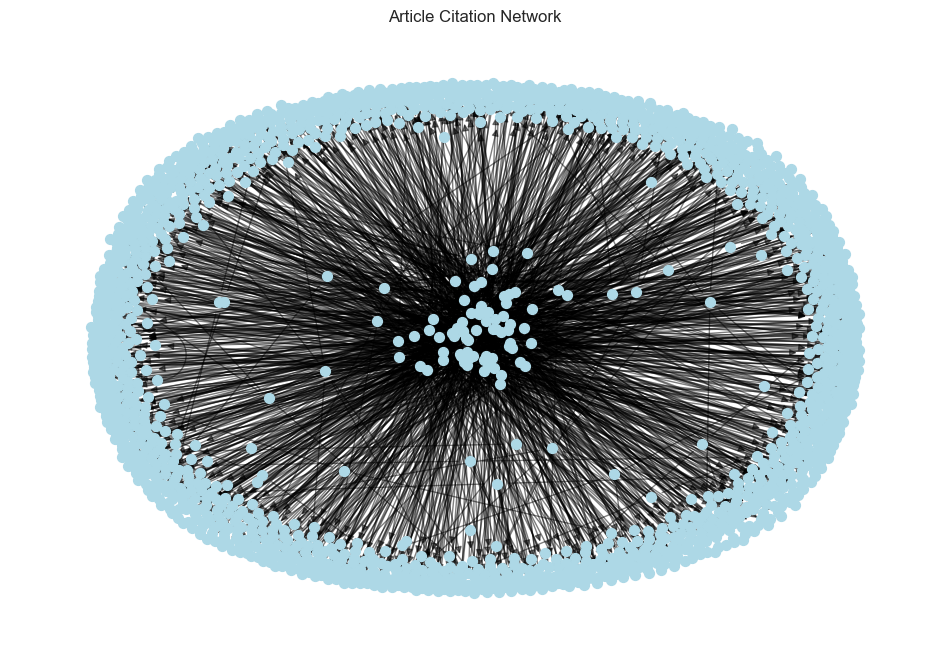

GML file saved at: article_citation_network.gml


In [39]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
# file_path = "/mnt/data/pyalexDumpJSON.txt"
# with open(file_path, "r", encoding="utf-8") as f:
#     data = json.load(f)

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges
for article in data:
    article_id = article["id"]
    G.add_node(article_id)  # Add the article as a node

    # Add edges for all referenced works
    referenced_works = article.get("referenced_works", [])
    for referenced_id in referenced_works:
        G.add_edge(article_id, referenced_id)

# Save the graph as a GML file
gml_file_path = "article_citation_network.gml"
nx.write_gml(G, gml_file_path)

# Visualize the graph (optional)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Layout for consistent positioning
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="lightblue")
nx.draw_networkx_edges(G, pos, alpha=0.5, arrows=True)
plt.title("Article Citation Network")
plt.axis("off")
plt.show()

# Output the file path for confirmation
print(f"GML file saved at: {gml_file_path}")

In [40]:
len(data)

166

In [41]:
import networkx as nx

# Load the GML file
gml_file_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\article_citation_network.gml"
G = nx.read_gml(gml_file_path)

# Get the list of nodes
nodes = list(G.nodes)

# Verify uniqueness
unique_nodes = set(nodes)
if len(nodes) == len(unique_nodes):
    print("All nodes are unique!")
else:
    print("There are duplicate nodes!")

# Output the total number of nodes
print(f"Total number of nodes: {len(nodes)}")
print(f"Number of unique nodes: {len(unique_nodes)}")

# Display the nodes if needed
print("List of nodes:")
# for node in unique_nodes:
#     print(node)

All nodes are unique!
Total number of nodes: 1694
Number of unique nodes: 1694
List of nodes:


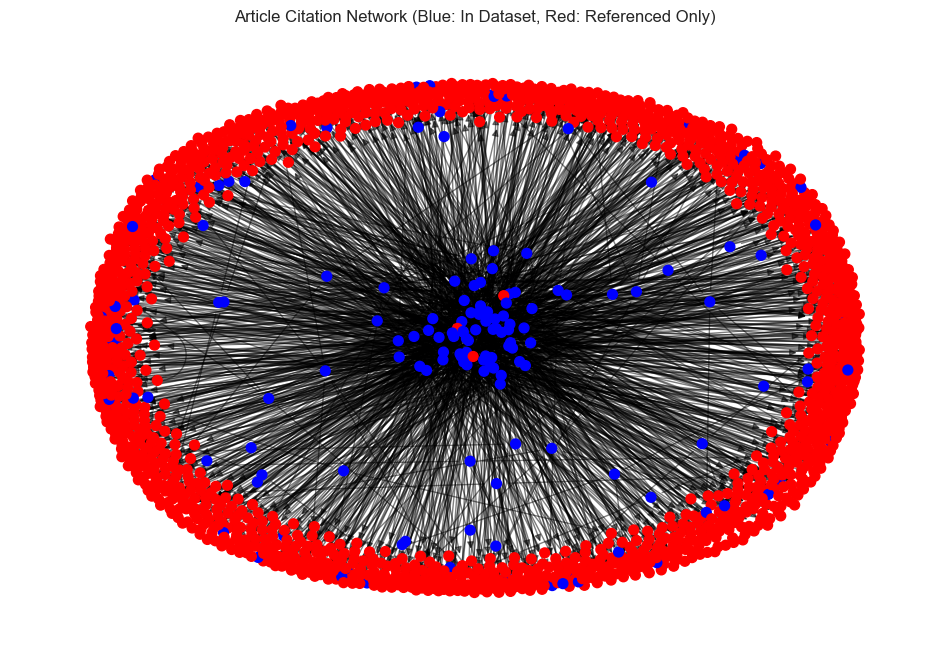

GML file saved at: article_citation_network_colored.gml


In [43]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
# file_path = "/mnt/data/pyalexDumpJSON.txt"
# with open(file_path, "r", encoding="utf-8") as f:
#     data = json.load(f)

# Create a directed graph
G = nx.DiGraph()

# Collect article IDs in the dataset
dataset_articles = {article["id"] for article in data}

# Add all articles as nodes and mark whether they're in the dataset
for article in data:
    article_id = article["id"]
    G.add_node(article_id, in_data=True)  # Node is part of the dataset

    # Add edges for referenced works
    referenced_works = article.get("referenced_works", [])
    for referenced_id in referenced_works:
        G.add_node(referenced_id, in_data=False)  # Referenced, not in dataset
        G.add_edge(article_id, referenced_id)

# Assign colors based on whether nodes are in the dataset
node_colors = [
    "blue" if G.nodes[node].get("in_data") else "red"
    for node in G.nodes
]

# Visualize the graph with color differentiation
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Consistent positioning
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors)
nx.draw_networkx_edges(G, pos, alpha=0.5, arrows=True)
plt.title("Article Citation Network (Blue: In Dataset, Red: Referenced Only)")
plt.axis("off")
plt.show()

# Save the graph as a GML file for Gephi
gml_file_path = "article_citation_network_colored.gml"
nx.write_gml(G, gml_file_path)
print(f"GML file saved at: {gml_file_path}")


In [44]:
print("Edges:")
for edge in list(G.edges)[:10]:  # Show first 10 edges
    print(edge)

Edges:
('https://openalex.org/W4388124931', 'https://openalex.org/W3210178340')
('https://openalex.org/W4389127150', 'https://openalex.org/W3198441341')
('https://openalex.org/W4389381587', 'https://openalex.org/W3210201227')
('https://openalex.org/W4389371056', 'https://openalex.org/W4220766059')
('https://openalex.org/W4389398875', 'https://openalex.org/W3206639986')
('https://openalex.org/W4389668371', 'https://openalex.org/W3205718487')
('https://openalex.org/W4391221390', 'https://openalex.org/W3147746887')
('https://openalex.org/W4387089889', 'https://openalex.org/W4281492574')
('https://openalex.org/W4384827242', 'https://openalex.org/W4280613470')
('https://openalex.org/W4384817808', 'https://openalex.org/W4229081703')


In [45]:
for node in list(G.nodes)[:10]:  # Show for first 10 nodes
    print(f"Node: {node}, In-Degree: {G.in_degree(node)}, Out-Degree: {G.out_degree(node)}")

Node: https://openalex.org/W4388124931, In-Degree: 0, Out-Degree: 1
Node: https://openalex.org/W3210178340, In-Degree: 1, Out-Degree: 0
Node: https://openalex.org/W4389127150, In-Degree: 0, Out-Degree: 1
Node: https://openalex.org/W3198441341, In-Degree: 1, Out-Degree: 0
Node: https://openalex.org/W4389381587, In-Degree: 0, Out-Degree: 1
Node: https://openalex.org/W3210201227, In-Degree: 1, Out-Degree: 0
Node: https://openalex.org/W4389371056, In-Degree: 0, Out-Degree: 1
Node: https://openalex.org/W4220766059, In-Degree: 1, Out-Degree: 0
Node: https://openalex.org/W4389398875, In-Degree: 0, Out-Degree: 1
Node: https://openalex.org/W3206639986, In-Degree: 1, Out-Degree: 0
